In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

In [2]:
import fsspec
from zipfile import ZipFile
from io import BytesIO

def load_specific_csv_from_zip(url, filename):
    """Load one specific CSV from multi-file ZIP"""
    with fsspec.open(url, 'rb') as f:
        with ZipFile(BytesIO(f.read())) as z:
            return pd.read_csv(z.open(filename),low_memory=False)

def load_csv_chunks_from_zip(url, filename, chunksize=500_000):
    with fsspec.open(url, 'rb') as f:
        with ZipFile(f) as z:
            for chunk in pd.read_csv(
                z.open(filename),
                low_memory=False,
                chunksize=chunksize
            ):
                yield chunk

url = "gs://agntworks-data-dev/wheelsup/raw/AgntWorks.zip"



In [3]:
booked_flights = load_specific_csv_from_zip(url, 'AgntWorks/booked_flights.csv')

In [4]:
requests_for_quotes = load_specific_csv_from_zip(url, 'AgntWorks/requests_for_quotes.csv')

In [5]:
search_activity = load_specific_csv_from_zip(url, 'AgntWorks/search_activity.csv')

In [6]:
# search_results = load_specific_csv_from_zip(url, 'AgntWorks/search_results.csv')

In [7]:
pricing_overrides = load_specific_csv_from_zip(url, 'AgntWorks/pricing_overrides.csv')

In [8]:
search_activity_corridor = pd.read_csv("gs://agntworks-data-dev/wheelsup/raw/search_activity_route_split.csv", parse_dates=['createDate_et'])

In [9]:
PREMIUM_CORRIDORS = [
    ('NEW_YORK_CLUSTER',      'MIAMI_CLUSTER'),
    ('ATLANTA_CLUSTER',       'MIAMI_CLUSTER'),
    ('WASHINGTON_DC_CLUSTER', 'ATLANTA_CLUSTER'),
]

C1 = '#1a237e'   # dark blue
C2 = '#f57c00'   # orange
C3 = '#2ecc71'   # green
C4 = '#e74c3c'   # red
CMAP = LinearSegmentedColormap.from_list('wu', ['#f0f3ff', '#1a237e'])

In [25]:
# ════════════════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════════════════
print('Loading datasets...')
bf   = booked_flights.copy()
rfq  = requests_for_quotes.copy()
legs = search_activity_corridor.copy()
po   = pricing_overrides.copy()

# search_results: large (7.4M) — aggregate on load via chunking
print('Chunking search_results...')
# sr_chunks = []

# for chunk in load_csv_chunks_from_zip(url, 'AgntWorks/search_results.csv'):
#     sr_chunks.append(
#         chunk[[
#             'singleSearchRequestId',
#             'aircraftCategoryName',
#             'displayPrice',
#             'crossOutPrice',
#             'programPrice',
#             'marketPrice',
#             'instantBook',
#             'flightTime',
#             'departureDate'
#         ]]
#     )


# sr = pd.concat(sr_chunks, ignore_index=True)

# Derived
legs['abandoned'] = legs['isCartAbandoned'].astype(str).str.lower().eq('true')
legs['corridor']  = legs['from_cluster'].str.replace('_CLUSTER','') + ' -> ' + legs['to_cluster'].str.replace('_CLUSTER','')
bf['substituted'] = bf['flightrequestedAircraftTypeName'] != bf['flightactualAircraftTypeName']
bf['billed_delta'] = bf['flightActualBilledHours'] - bf['flightEstimatedBilledHours']

print(f'booked_flights : {len(bf):,}')
print(f'rfq            : {len(rfq):,}')
print(f'legs           : {len(legs):,}')
# print(f'search_results : {len(sr):,}')
print(f'pricing_over.  : {len(po):,}')

Loading datasets...
Chunking search_results...
booked_flights : 258,370
rfq            : 31,077
legs           : 1,183,154
pricing_over.  : 578,576


## Section 1 — Funnel & Conversion

**Q1**: Which corridors have the biggest search-to-book gap?  
**Q2**: How does cart abandonment trend week-over-week?  
**Q3**: What does the RFQ quote lifecycle look like — where do deals fall out?

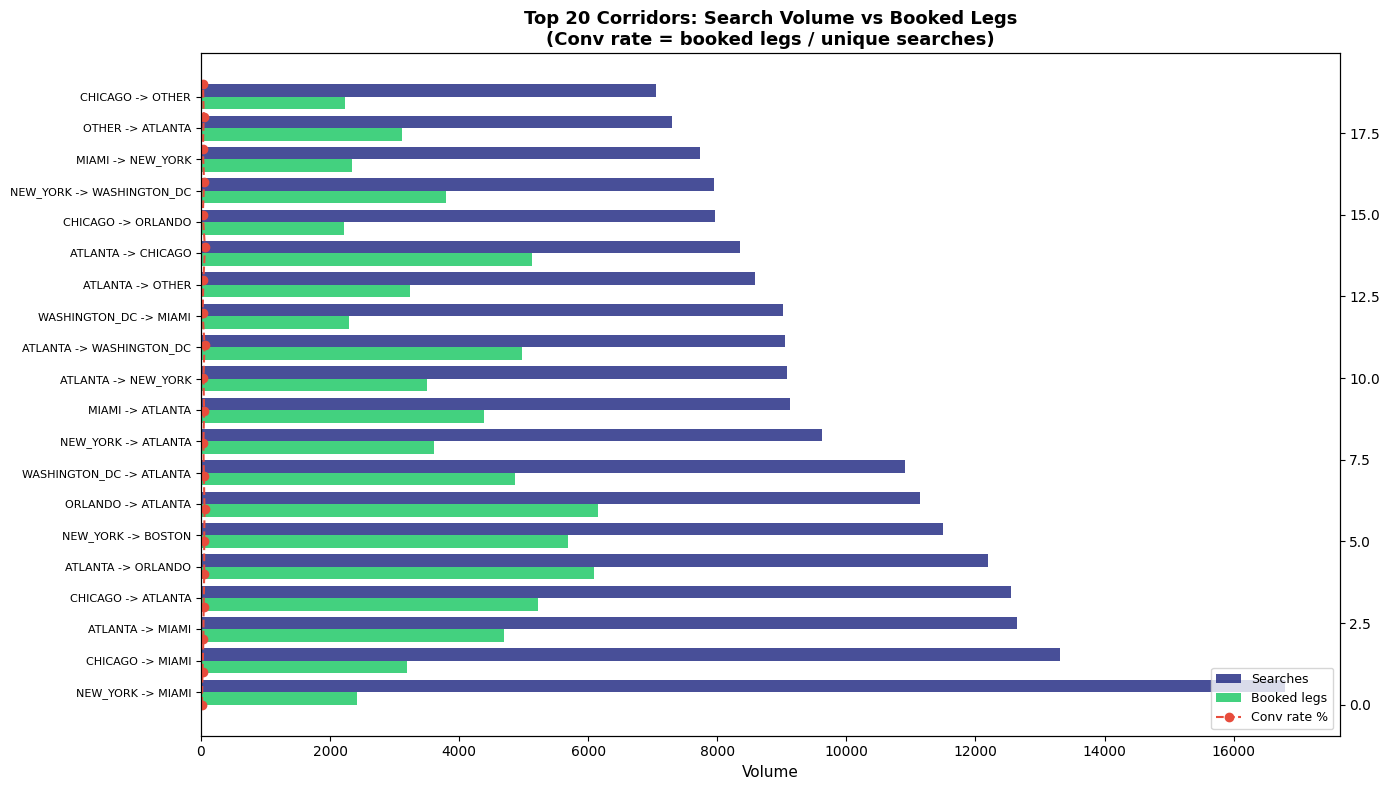


Lowest conversion corridors (high search, low book):
                        searches  booked_legs  conv_rate
corridor                                                
NEW_YORK -> MIAMI          16801         2422   0.144158
CHICAGO -> MIAMI           13312         3186   0.239333
WASHINGTON_DC -> MIAMI      9011         2300   0.255244
CHICAGO -> ORLANDO          7971         2218   0.278259
MIAMI -> NEW_YORK           7736         2339   0.302353


In [26]:
# Q1 — Search volume vs booked legs per corridor
# Search side: unique searches per corridor (from legs, excluding same-cluster)
search_corr = (
    legs[legs['from_cluster'] != legs['to_cluster']]
    .drop_duplicates('singleSearchRequestId')
    .groupby('corridor')
    .size()
    .rename('searches')
)

# Booked side: build corridor from booked_flights airport columns
# Map airports to clusters using icao_cluster
icao_map = pd.read_csv('gs://agntworks-data-dev/sandbox/experiments/icao_cluster.csv')
cluster_dict = dict(zip(icao_map['icao'], icao_map['cluster']))

bf['from_cluster'] = bf['flightoriginAirport'].map(cluster_dict).fillna('OTHER')
bf['to_cluster']   = bf['flightdestinationAirport'].map(cluster_dict).fillna('OTHER')
bf['corridor']     = bf['from_cluster'].str.replace('_CLUSTER','') + ' -> ' + bf['to_cluster'].str.replace('_CLUSTER','')

booked_corr = (
    bf[bf['from_cluster'] != bf['to_cluster']]
    .groupby('corridor')
    .size()
    .rename('booked_legs')
)

funnel = pd.concat([search_corr, booked_corr], axis=1).fillna(0).astype(int)
funnel = funnel[funnel['searches'] >= 300].copy()
funnel['conv_rate'] = funnel['booked_legs'] / funnel['searches']
funnel = funnel.sort_values('searches', ascending=False).head(20)

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()
y = range(len(funnel))
ax1.barh(y, funnel['searches'],  color=C1, alpha=0.8, label='Searches',    height=0.4, align='edge')
ax1.barh(y, funnel['booked_legs'], color=C3, alpha=0.9, label='Booked legs', height=-0.4, align='edge')
ax2.plot(funnel['conv_rate']*100, y, 'o--', color=C4, ms=6, lw=1.5, label='Conv rate %')
ax1.set_yticks(y)
ax1.set_yticklabels(funnel.index, fontsize=8)
ax1.set_xlabel('Volume', fontsize=11)
ax2.set_xlabel('Conversion Rate (%)', fontsize=11)
ax1.set_title('Top 20 Corridors: Search Volume vs Booked Legs\n(Conv rate = booked legs / unique searches)',
              fontsize=13, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('qa_funnel_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nLowest conversion corridors (high search, low book):')
print(funnel.nsmallest(5,'conv_rate')[['searches','booked_legs','conv_rate']].to_string())

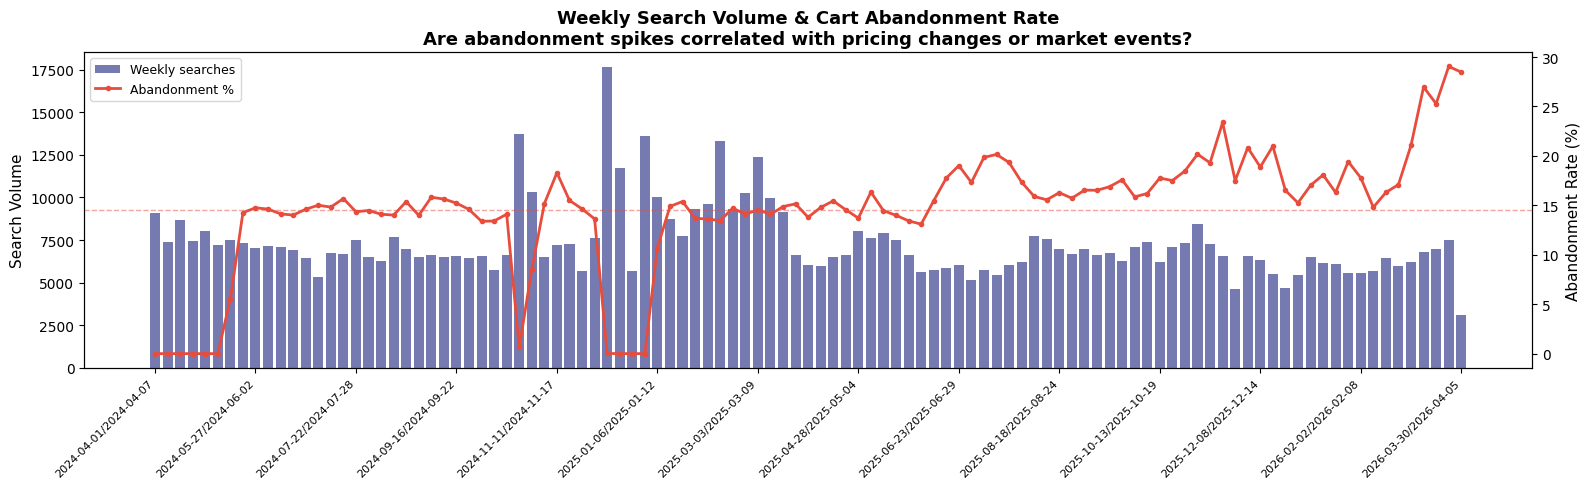

Overall avg abandonment: 14.6%
Peak abandonment week  :                  week  abnd_rate
2026-03-23/2026-03-29   0.290413


In [27]:
# Q2 — Weekly abandonment trend
weekly = (
    legs.drop_duplicates('singleSearchRequestId')
    .assign(week=lambda d: d['createDate_et'].dt.to_period('W').astype(str))
    .groupby('week')
    .agg(searches=('singleSearchRequestId','count'),
         abandoned=('abandoned','sum'))
    .reset_index()
)
weekly['abnd_rate'] = weekly['abandoned'] / weekly['searches']
# keep weeks with enough volume
weekly = weekly[weekly['searches'] >= 500]

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.bar(range(len(weekly)), weekly['searches'], color=C1, alpha=0.6, label='Weekly searches')
ax2.plot(range(len(weekly)), weekly['abnd_rate']*100, color=C4, lw=2, marker='o', ms=3, label='Abandonment %')
ax2.axhline(weekly['abnd_rate'].mean()*100, color=C4, lw=1, ls='--', alpha=0.5)
step = max(1, len(weekly)//12)
ax1.set_xticks(range(0, len(weekly), step))
ax1.set_xticklabels(weekly['week'].iloc[::step], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Search Volume', fontsize=11)
ax2.set_ylabel('Abandonment Rate (%)', fontsize=11)
ax1.set_title('Weekly Search Volume & Cart Abandonment Rate\nAre abandonment spikes correlated with pricing changes or market events?',
              fontsize=13, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('qa_abandonment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall avg abandonment: {weekly["abnd_rate"].mean()*100:.1f}%')
print(f'Peak abandonment week  : {weekly.nlargest(1,"abnd_rate")[["week","abnd_rate"]].to_string(index=False)}')

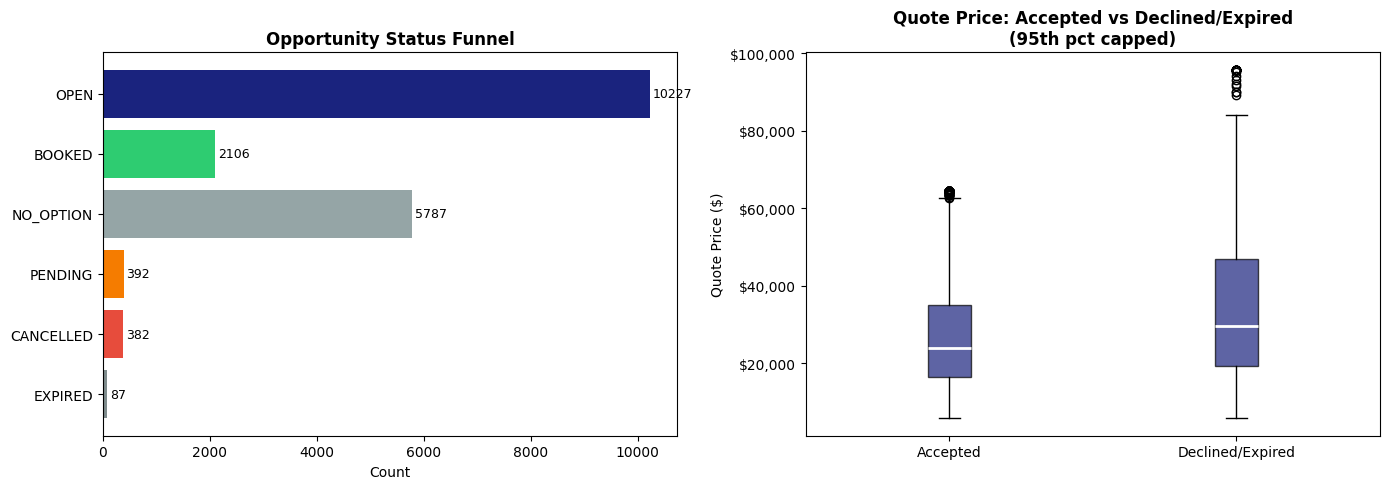

=== Opportunity Status ===
opportunityStatus
OPEN         10227
NO_OPTION     5787
BOOKED        2106
PENDING        392
CANCELLED      382
EXPIRED         87
REOPENED         9
DECLINED         3
QUOTED           2

=== Quote Option Status ===
quoteOptionStatus
ACCEPTED    2106
EXPIRED      205
REVOKED      178
READY         16
DECLINED       4

Accepted median price : $23,956
Declined median price : $29,562


In [28]:
# Q3 — RFQ quote lifecycle funnel
opp_status = rfq.drop_duplicates('opportunityId')['opportunityStatus'].value_counts()
quote_status = rfq.dropna(subset=['opportunityQuoteOptionId']).drop_duplicates('opportunityQuoteOptionId')['quoteOptionStatus'].value_counts()

# Price distribution: accepted vs declined/expired
quote_prices = (
    rfq.dropna(subset=['quoteOptionStatus','quoteOptionPrice'])
    .drop_duplicates('opportunityQuoteOptionId')
    .assign(outcome=lambda d: d['quoteOptionStatus'].map(
        lambda s: 'Accepted' if s=='ACCEPTED' else ('Declined/Expired' if s in ('DECLINED','EXPIRED','REVOKED') else 'Other')
    ))
    .query('outcome != "Other"')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: opportunity funnel
opp_order = ['OPEN','BOOKED','NO_OPTION','PENDING','CANCELLED','EXPIRED']
opp_vals  = opp_status.reindex(opp_order).fillna(0)
colors_opp = [C1, C3, '#95a5a6', C2, C4, '#7f8c8d']
axes[0].barh(opp_vals.index[::-1], opp_vals.values[::-1], color=colors_opp[::-1])
axes[0].set_title('Opportunity Status Funnel', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(opp_vals.values[::-1]):
    axes[0].text(v+50, i, str(int(v)), va='center', fontsize=9)

# Right: price by outcome (box)
accepted = quote_prices[quote_prices['outcome']=='Accepted']['quoteOptionPrice'].dropna()
declined = quote_prices[quote_prices['outcome']=='Declined/Expired']['quoteOptionPrice'].dropna()
axes[1].boxplot([accepted.clip(upper=accepted.quantile(0.95)),
                 declined.clip(upper=declined.quantile(0.95))],
                labels=['Accepted','Declined/Expired'],
                patch_artist=True,
                boxprops=dict(facecolor=C1, alpha=0.7),
                medianprops=dict(color='white', lw=2))
axes[1].set_title('Quote Price: Accepted vs Declined/Expired\n(95th pct capped)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Quote Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('qa_rfq_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Opportunity Status ===')
print(opp_status.to_string())
print('\n=== Quote Option Status ===')
print(quote_status.to_string())
print(f'\nAccepted median price : ${accepted.median():,.0f}')
print(f'Declined median price : ${declined.median():,.0f}')

## Section 2 — Pricing Intelligence

**Q4**: How large is the display-price markdown (cross-out price) and which cabin types use it most?  
**Q5**: How active is ToD variance in pricing overrides — and which routes/cabins are covered?  
**Q6**: How does WU's program price compare to market price by cabin type?

Results with cross-out price: 644,442 / 7,438,382 (8.7%)
Avg markdown: 11.7%


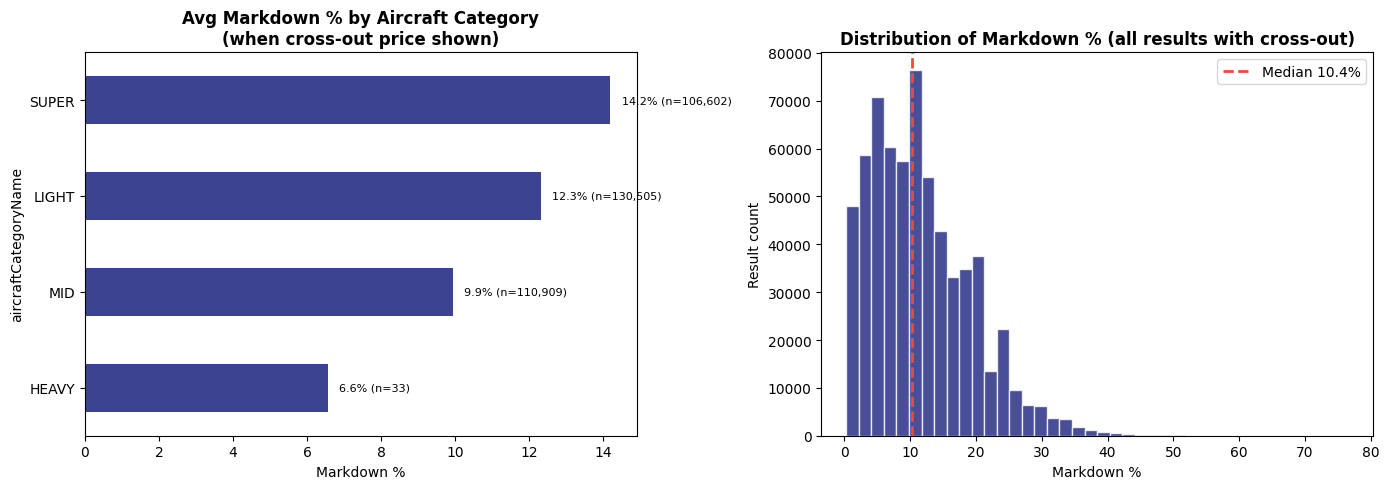

In [29]:
# Q4 — Display price vs cross-out price (markdown signal)
sr_marked = sr[(sr['crossOutPrice'] > 0) & (sr['displayPrice'] > 0)].copy()
sr_marked['markdown_pct'] = (sr_marked['crossOutPrice'] - sr_marked['displayPrice']) / sr_marked['crossOutPrice'] * 100
sr_marked = sr_marked[sr_marked['markdown_pct'].between(0, 80)]  # remove outliers

print(f'Results with cross-out price: {len(sr_marked):,} / {len(sr):,} ({len(sr_marked)/len(sr)*100:.1f}%)')
print(f'Avg markdown: {sr_marked["markdown_pct"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: markdown % by cabin
cabin_mkd = (
    sr_marked.groupby('aircraftCategoryName')['markdown_pct']
    .agg(['mean','median','count'])
    .sort_values('mean', ascending=True)
)
cabin_mkd['mean'].plot(kind='barh', ax=axes[0], color=C1, alpha=0.85)
axes[0].set_title('Avg Markdown % by Aircraft Category\n(when cross-out price shown)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Markdown %')
for i, (v, cnt) in enumerate(zip(cabin_mkd['mean'], cabin_mkd['count'])):
    axes[0].text(v+0.3, i, f'{v:.1f}% (n={cnt:,})', va='center', fontsize=8)

# Right: markdown % distribution
axes[1].hist(sr_marked['markdown_pct'], bins=40, color=C1, alpha=0.8, edgecolor='white')
axes[1].axvline(sr_marked['markdown_pct'].median(), color=C4, lw=2, ls='--', label=f'Median {sr_marked["markdown_pct"].median():.1f}%')
axes[1].set_title('Distribution of Markdown % (all results with cross-out)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Markdown %')
axes[1].set_ylabel('Result count')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('qa_markdown_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Total override rules  : 578,576
Active rules          : 245,370 (42.4%)
Active with ToD var.  : 28,909 (11.8% of active)


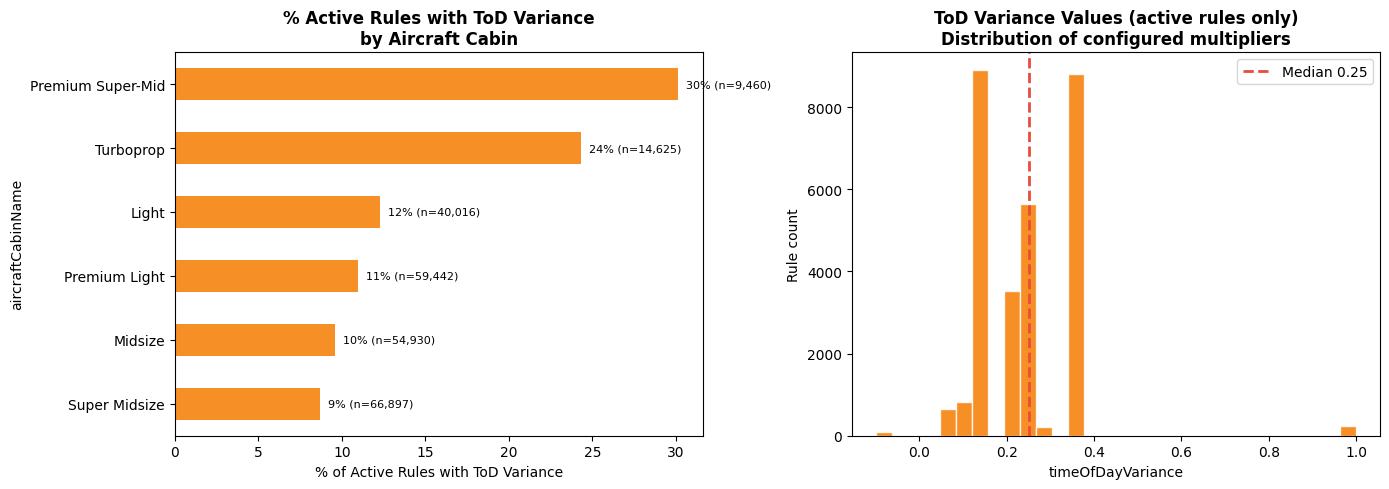


ToD variance stats (active non-zero):
count    28909.000000
mean         0.240351
std          0.114359
min         -0.100000
25%          0.150000
50%          0.250000
75%          0.350000
max          1.000000
Name: timeOfDayVariance, dtype: float64


In [30]:
# Q5 — ToD variance coverage in pricing overrides
po_active = po[po['active'] == True].copy()
po_active['has_tod'] = po_active['timeOfDayVariance'].fillna(0) != 0

print(f'Total override rules  : {len(po):,}')
print(f'Active rules          : {len(po_active):,} ({len(po_active)/len(po)*100:.1f}%)')
print(f'Active with ToD var.  : {po_active["has_tod"].sum():,} ({po_active["has_tod"].mean()*100:.1f}% of active)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ToD coverage by cabin
tod_cabin = (
    po_active.groupby('aircraftCabinName')['has_tod']
    .agg(['sum','count'])
    .assign(pct=lambda d: d['sum']/d['count']*100)
    .sort_values('pct', ascending=True)
)
tod_cabin['pct'].plot(kind='barh', ax=axes[0], color=C2, alpha=0.85)
axes[0].set_title('% Active Rules with ToD Variance\nby Aircraft Cabin', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% of Active Rules with ToD Variance')
for i, (pct, cnt) in enumerate(zip(tod_cabin['pct'], tod_cabin['count'])):
    axes[0].text(pct+0.5, i, f'{pct:.0f}% (n={cnt:,})', va='center', fontsize=8)

# Right: ToD variance distribution (non-zero active)
tod_vals = po_active[po_active['has_tod']]['timeOfDayVariance'].dropna()
axes[1].hist(tod_vals, bins=30, color=C2, alpha=0.85, edgecolor='white')
axes[1].axvline(tod_vals.median(), color=C4, lw=2, ls='--', label=f'Median {tod_vals.median():.2f}')
axes[1].set_title('ToD Variance Values (active rules only)\nDistribution of configured multipliers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('timeOfDayVariance')
axes[1].set_ylabel('Rule count')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('qa_tod_overrides.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nToD variance stats (active non-zero):')
print(tod_vals.describe())

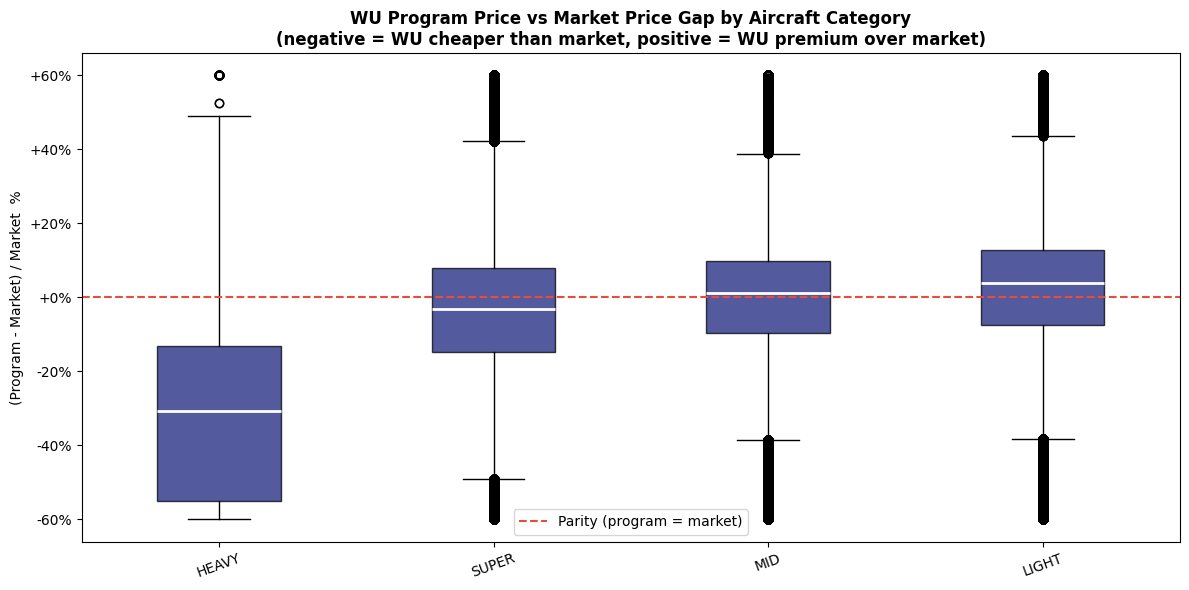

Avg program-vs-market gap by cabin:
                           mean     median    count
aircraftCategoryName                               
HEAVY                -32.229517 -30.829231   174171
SUPER                 -4.379866  -3.062787   967255
MID                   -0.024645   1.163467  1146989
LIGHT                  2.675328   3.799873  1356236


In [31]:
# Q6 — Program price vs market price gap by cabin type
sr_priced = sr[
    (sr['programPrice'] > 0) &
    (sr['marketPrice'] > 0) &
    sr['aircraftCategoryName'].notna()
].copy()
sr_priced['gap_pct'] = (sr_priced['programPrice'] - sr_priced['marketPrice']) / sr_priced['marketPrice'] * 100
sr_priced['gap_pct'] = sr_priced['gap_pct'].clip(-60, 60)

cabin_order = (
    sr_priced.groupby('aircraftCategoryName')['gap_pct']
    .mean().sort_values().index
)

fig, ax = plt.subplots(figsize=(12, 6))
data_by_cabin = [sr_priced[sr_priced['aircraftCategoryName']==c]['gap_pct'].dropna() for c in cabin_order]
bp = ax.boxplot(data_by_cabin, labels=cabin_order, patch_artist=True, vert=True,
                medianprops=dict(color='white', lw=2))
for patch in bp['boxes']:
    patch.set_facecolor(C1)
    patch.set_alpha(0.75)
ax.axhline(0, color=C4, lw=1.5, ls='--', label='Parity (program = market)')
ax.set_title('WU Program Price vs Market Price Gap by Aircraft Category\n(negative = WU cheaper than market, positive = WU premium over market)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('(Program - Market) / Market  %')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:+.0f}%'))
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('qa_program_vs_market.png', dpi=150, bbox_inches='tight')
plt.show()

print('Avg program-vs-market gap by cabin:')
print(sr_priced.groupby('aircraftCategoryName')['gap_pct'].agg(['mean','median','count']).sort_values('mean').to_string())

## Section 3 — Aircraft & Operations

**Q7**: Aircraft substitution — how often, which cabins, and is there a cost impact?  
**Q8**: Estimated vs actual billed hours — which cabin types consistently overbill or underbill?

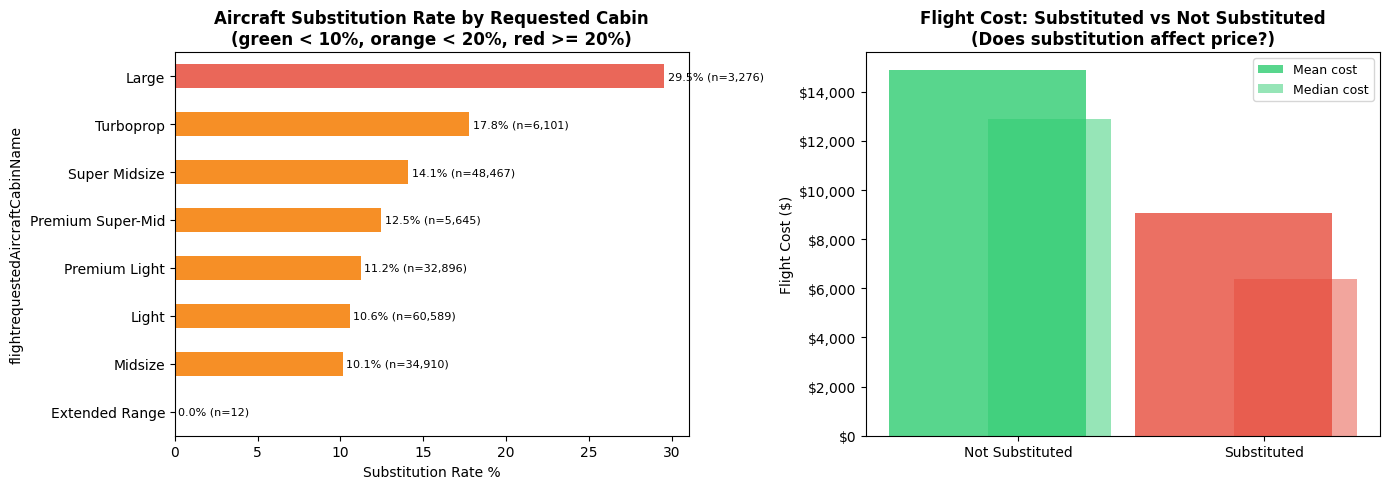

Overall substitution rate: 14.1%
                     mean    median   count
substituted                                
False        14869.470265  12911.50  221425
True          9077.388479   6384.82   35659


In [32]:
# Q7 — Aircraft substitution rate and cost impact
sub_cabin = (
    bf.groupby('flightrequestedAircraftCabinName')
    .agg(total=('substituted','count'),
         substituted=('substituted','sum'))
    .assign(sub_rate=lambda d: d['substituted']/d['total']*100)
    .sort_values('sub_rate', ascending=True)
)

cost_comp = (
    bf.dropna(subset=['flightcost'])
    .groupby('substituted')['flightcost']
    .agg(['mean','median','count'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: substitution rate by cabin
colors_sub = [C3 if r < 10 else C2 if r < 20 else C4 for r in sub_cabin['sub_rate']]
sub_cabin['sub_rate'].plot(kind='barh', ax=axes[0], color=colors_sub, alpha=0.85)
axes[0].set_title('Aircraft Substitution Rate by Requested Cabin\n(green < 10%, orange < 20%, red >= 20%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Substitution Rate %')
for i, (rate, cnt) in enumerate(zip(sub_cabin['sub_rate'], sub_cabin['total'])):
    axes[0].text(rate+0.2, i, f'{rate:.1f}% (n={cnt:,})', va='center', fontsize=8)

# Right: cost comparison substituted vs not
labels = ['Not Substituted', 'Substituted']
means  = [cost_comp.loc[False,'mean'],  cost_comp.loc[True,'mean']]
medians= [cost_comp.loc[False,'median'], cost_comp.loc[True,'median']]
x = [0, 1]
axes[1].bar([0,1], means,   color=[C3, C4], alpha=0.8, label='Mean cost')
axes[1].bar([0.25,1.25], medians, color=[C3, C4], alpha=0.5, width=0.5, label='Median cost')
axes[1].set_xticks([0.125, 1.125])
axes[1].set_xticklabels(labels)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].set_title('Flight Cost: Substituted vs Not Substituted\n(Does substitution affect price?)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Flight Cost ($)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('qa_substitution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall substitution rate: {bf["substituted"].mean()*100:.1f}%')
print(cost_comp.to_string())

Type-level substitution  : 14.1%
Cabin-level substitution : 39.5%

Of 102,155 cabin substitutions:
  Same        : 68,570 (67.1%)
  Upgrade     : 26,743 (26.2%)
  Downgrade   : 6,842 (6.7%)


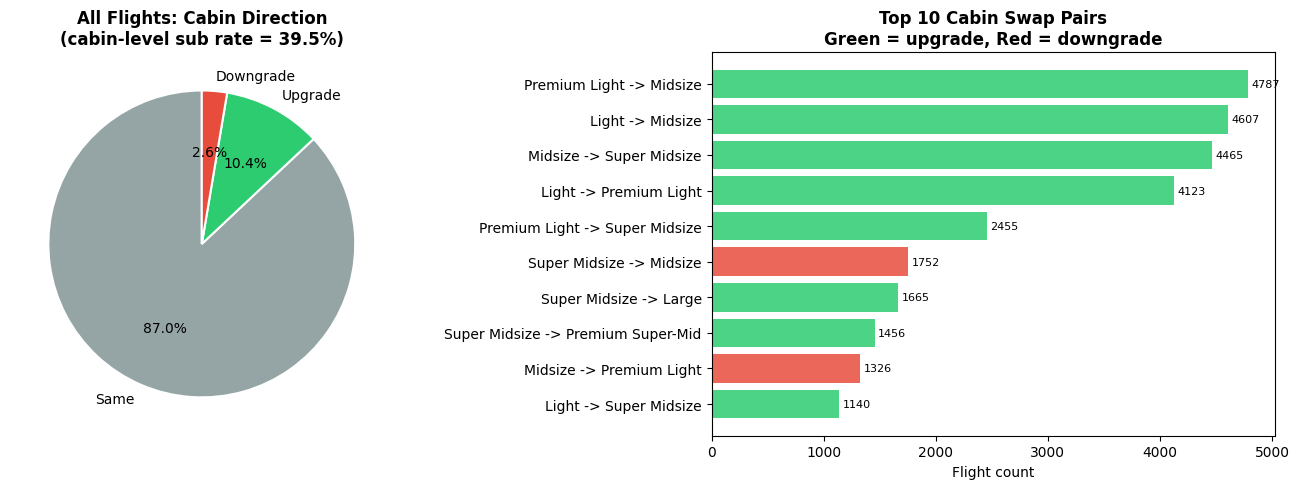


Top cabin swap pairs:
                             label  count       dir
          Premium Light -> Midsize   4787   Upgrade
                  Light -> Midsize   4607   Upgrade
          Midsize -> Super Midsize   4465   Upgrade
            Light -> Premium Light   4123   Upgrade
    Premium Light -> Super Midsize   2455   Upgrade
          Super Midsize -> Midsize   1752 Downgrade
            Super Midsize -> Large   1665   Upgrade
Super Midsize -> Premium Super-Mid   1456   Upgrade
          Midsize -> Premium Light   1326 Downgrade
            Light -> Super Midsize   1140   Upgrade


In [33]:
# Q7b — Cabin-level substitution (more meaningful than type-level)
bf["cabin_sub"] = bf["flightrequestedAircraftCabinName"] != bf["flightactualAircraftCabinName"]

CABIN_RANK = {"Light":1,"Premium Light":2,"Midsize":3,"Super Midsize":4,
              "Premium Super-Mid":5,"Large":6,"Turboprop":0}
bf["req_rank"] = bf["flightrequestedAircraftCabinName"].map(CABIN_RANK)
bf["act_rank"] = bf["flightactualAircraftCabinName"].map(CABIN_RANK)
bf["direction"] = bf.apply(
    lambda r: "Upgrade" if pd.notna(r["act_rank"]) and pd.notna(r["req_rank"]) and r["act_rank"] > r["req_rank"]
    else ("Downgrade" if pd.notna(r["act_rank"]) and pd.notna(r["req_rank"]) and r["act_rank"] < r["req_rank"] else "Same"),
    axis=1
)

cabin_rate = bf["cabin_sub"].mean() * 100
type_rate  = bf["substituted"].mean() * 100
print(f"Type-level substitution  : {type_rate:.1f}%")
print(f"Cabin-level substitution : {cabin_rate:.1f}%")

cabin_subs = bf[bf["cabin_sub"]].copy()
dir_counts = cabin_subs["direction"].value_counts()
print(f'\nOf {len(cabin_subs):,} cabin substitutions:')
for d, n in dir_counts.items():
    print(f"  {d:12s}: {n:,} ({n/len(cabin_subs)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: upgrade vs downgrade vs same (pie — all flights)
dir_all = bf["direction"].value_counts()
colors_dir = {"Upgrade": C3, "Same": "#95a5a6", "Downgrade": C4}
axes[0].pie(dir_all, labels=dir_all.index, autopct="%1.1f%%",
            colors=[colors_dir[k] for k in dir_all.index],
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title(f"All Flights: Cabin Direction\n(cabin-level sub rate = {cabin_rate:.1f}%)",
                  fontsize=12, fontweight="bold")

# Right: top 10 cabin swap pairs
swap_pairs = (
    cabin_subs
    .groupby(["flightrequestedAircraftCabinName","flightactualAircraftCabinName"])
    .size().sort_values(ascending=False).head(10).reset_index(name="count")
)
swap_pairs["label"] = swap_pairs["flightrequestedAircraftCabinName"] + " -> " + swap_pairs["flightactualAircraftCabinName"]
swap_pairs["dir"]   = swap_pairs.apply(
    lambda r: "Upgrade" if CABIN_RANK.get(r["flightactualAircraftCabinName"],0) > CABIN_RANK.get(r["flightrequestedAircraftCabinName"],0) else "Downgrade",
    axis=1
)
bar_colors = [C3 if d == "Upgrade" else C4 for d in swap_pairs["dir"][::-1]]
axes[1].barh(swap_pairs["label"][::-1], swap_pairs["count"][::-1],
             color=bar_colors, alpha=0.85)
axes[1].set_title("Top 10 Cabin Swap Pairs\nGreen = upgrade, Red = downgrade",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Flight count")
for i, v in enumerate(swap_pairs["count"][::-1]):
    axes[1].text(v+30, i, str(v), va="center", fontsize=8)

plt.tight_layout()
plt.savefig("qa_cabin_substitution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop cabin swap pairs:")
print(swap_pairs[["label","count","dir"]].to_string(index=False))

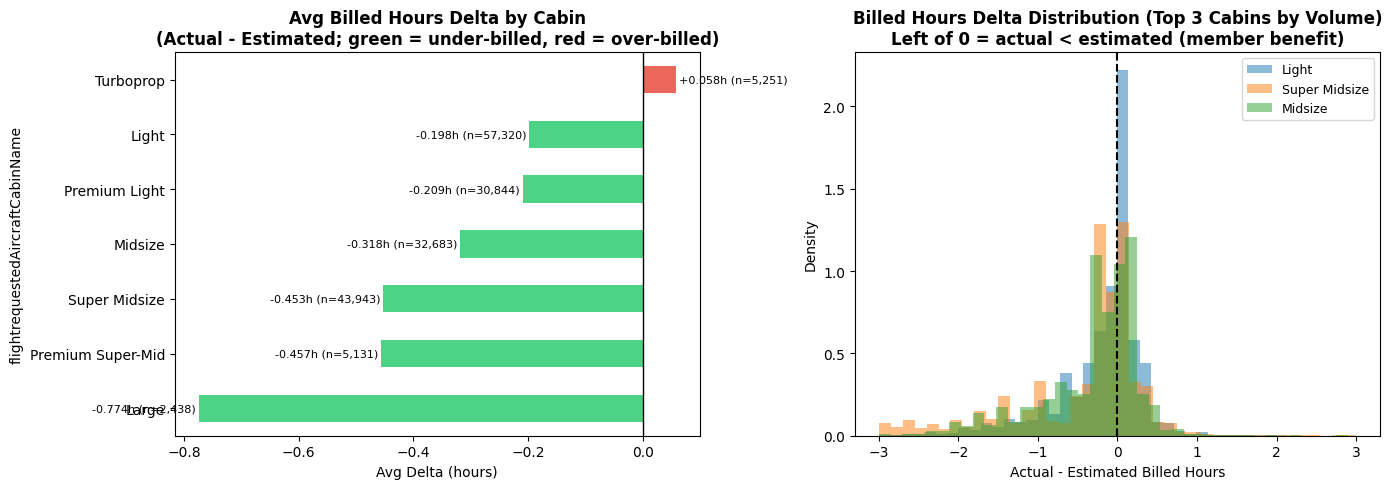

Billed hours delta by cabin:
                                      mean  median       std  count
flightrequestedAircraftCabinName                                   
Large                            -0.774364  -0.475  0.903431   2438
Premium Super-Mid                -0.456847  -0.100  1.005618   5131
Super Midsize                    -0.452951  -0.200  0.812200  43943
Midsize                          -0.318092  -0.100  0.619084  32683
Premium Light                    -0.209189   0.000  0.642018  30844
Light                            -0.198051  -0.080  0.544844  57320
Turboprop                         0.057623   0.000  0.317580   5251


In [34]:
# Q8 — Estimated vs actual billed hours delta by cabin
billed = bf.dropna(subset=['billed_delta','flightrequestedAircraftCabinName']).copy()
billed = billed[billed['billed_delta'].between(-3, 3)]  # clip extreme outliers

cabin_delta = (
    billed.groupby('flightrequestedAircraftCabinName')['billed_delta']
    .agg(['mean','median','std','count'])
    .sort_values('mean')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean delta per cabin
colors_delta = [C3 if m <= 0 else C4 for m in cabin_delta['mean']]
cabin_delta['mean'].plot(kind='barh', ax=axes[0], color=colors_delta, alpha=0.85)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('Avg Billed Hours Delta by Cabin\n(Actual - Estimated; green = under-billed, red = over-billed)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Delta (hours)')
for i, (v, cnt) in enumerate(zip(cabin_delta['mean'], cabin_delta['count'])):
    axes[0].text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:+.3f}h (n={cnt:,})',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# Right: distribution for top 3 cabins by count
top3 = cabin_delta.nlargest(3,'count').index
for cab in top3:
    vals = billed[billed['flightrequestedAircraftCabinName']==cab]['billed_delta']
    axes[1].hist(vals, bins=40, alpha=0.5, label=cab, density=True)
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_title('Billed Hours Delta Distribution (Top 3 Cabins by Volume)\nLeft of 0 = actual < estimated (member benefit)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual - Estimated Billed Hours')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('qa_billed_hours_delta.png', dpi=150, bbox_inches='tight')
plt.show()

print('Billed hours delta by cabin:')
print(cabin_delta.to_string())

## Section 4 — Member & Demand

**Q9**: How concentrated is demand on premium corridors — is it a small member cohort or broad?  
**Q10**: Weekend searches are serious buyers too — how does that compare to actual weekend bookings?  
**Q11**: Pricing override health — how many active rules, and what's the ToD coverage gap?

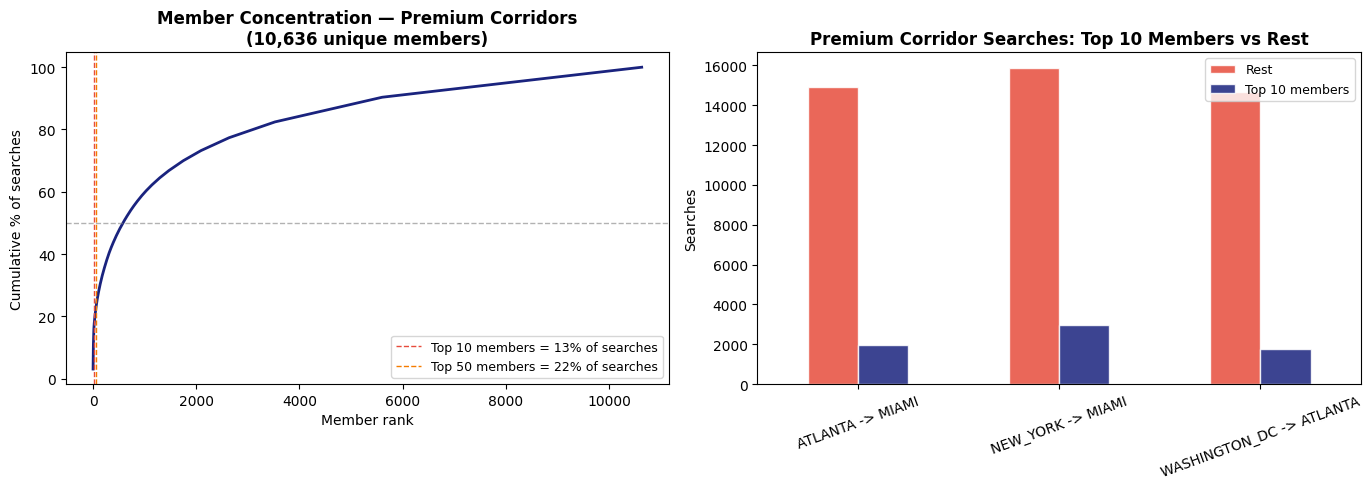

Unique members on premium corridors: 10,636
Top 10 members drive 12.9% of premium corridor searches
Top 50 members drive 21.9% of premium corridor searches


In [35]:
# Q9 — Member concentration on premium corridors
prem_mask = legs.apply(
    lambda r: (r['from_cluster'], r['to_cluster']) in PREMIUM_CORRIDORS, axis=1
)
prem_legs = legs[prem_mask].drop_duplicates('singleSearchRequestId')

member_counts = (
    prem_legs.dropna(subset=['memberId'])
    .groupby('memberId')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='searches')
)
member_counts['cumshare'] = member_counts['searches'].cumsum() / member_counts['searches'].sum()
member_counts['rank'] = range(1, len(member_counts)+1)

top10_share = member_counts[member_counts['rank'] <= 10]['searches'].sum() / member_counts['searches'].sum()
top50_share = member_counts[member_counts['rank'] <= 50]['searches'].sum() / member_counts['searches'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Lorenz-style cumulative share curve
axes[0].plot(member_counts['rank'], member_counts['cumshare']*100, color=C1, lw=2)
axes[0].axhline(50, color='grey', lw=1, ls='--', alpha=0.6)
axes[0].axvline(10, color=C4, lw=1, ls='--', label=f'Top 10 members = {top10_share*100:.0f}% of searches')
axes[0].axvline(50, color=C2, lw=1, ls='--', label=f'Top 50 members = {top50_share*100:.0f}% of searches')
axes[0].set_title(f'Member Concentration — Premium Corridors\n({len(member_counts):,} unique members)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Member rank')
axes[0].set_ylabel('Cumulative % of searches')
axes[0].legend(fontsize=9)

# Right: searches per corridor split per member bucket (top10 vs rest)
top10_ids = set(member_counts.head(10)['memberId'])
prem_legs['member_bucket'] = prem_legs['memberId'].apply(
    lambda m: 'Top 10 members' if m in top10_ids else 'Rest'
)
corr_bucket = (
    prem_legs.assign(corridor=lambda d: d['from_cluster'].str.replace('_CLUSTER','') + ' -> ' + d['to_cluster'].str.replace('_CLUSTER',''))
    .groupby(['corridor','member_bucket'])
    .size()
    .unstack('member_bucket')
    .fillna(0)
)
corr_bucket.plot(kind='bar', ax=axes[1], color=[C4, C1], alpha=0.85, edgecolor='white')
axes[1].set_title('Premium Corridor Searches: Top 10 Members vs Rest', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Searches')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('qa_member_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Unique members on premium corridors: {len(member_counts):,}')
print(f'Top 10 members drive {top10_share*100:.1f}% of premium corridor searches')
print(f'Top 50 members drive {top50_share*100:.1f}% of premium corridor searches')

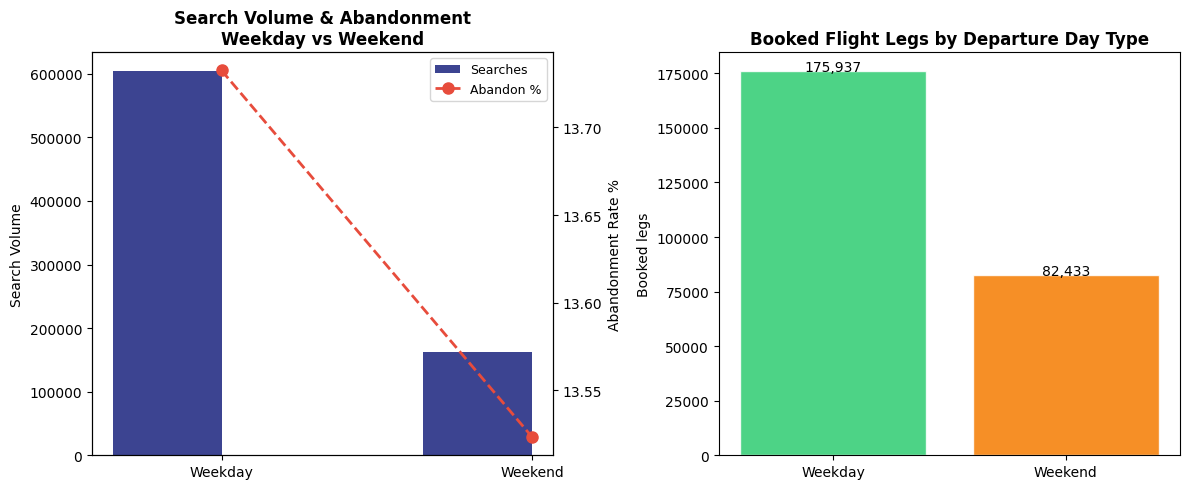

            searches  abandoned  abnd_rate
is_weekend                                
False         603919      82933   0.137325
True          161763      21876   0.135235

Booked legs by weekend flag:
is_weekend_dep
False    175937
True      82433


In [36]:
# Q10 — Weekend search intent vs weekend bookings
legs_uniq = legs.drop_duplicates('singleSearchRequestId').copy()
legs_uniq['is_weekend'] = legs_uniq['dow_et'].isin(['Saturday','Sunday'])

wkend_search = legs_uniq.groupby('is_weekend').agg(
    searches=('singleSearchRequestId','count'),
    abandoned=('abandoned','sum')
).assign(abnd_rate=lambda d: d['abandoned']/d['searches'])

# Booked flights: derive DOW from departure time
bf['dep_dt']    = pd.to_datetime(bf['flightEstimatedDepartureTime'], errors='coerce', utc=True)
bf['dep_et']    = bf['dep_dt'].dt.tz_convert('US/Eastern')
bf['dep_dow']   = bf['dep_et'].dt.day_name()
bf['is_weekend_dep'] = bf['dep_dow'].isin(['Saturday','Sunday'])

wkend_booked = bf.groupby('is_weekend_dep').size().rename('booked_legs')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Weekday', 'Weekend']
searches = [wkend_search.loc[False,'searches'], wkend_search.loc[True,'searches']]
abnd     = [wkend_search.loc[False,'abnd_rate']*100, wkend_search.loc[True,'abnd_rate']*100]
booked   = [wkend_booked.get(False,0), wkend_booked.get(True,0)]

x = [0,1]
w = 0.35
axes[0].bar([i-w/2 for i in x], searches, width=w, color=C1, alpha=0.85, label='Searches')
ax_r = axes[0].twinx()
ax_r.plot(x, abnd, 'o--', color=C4, ms=8, lw=2, label='Abandon %')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Search Volume')
ax_r.set_ylabel('Abandonment Rate %')
axes[0].set_title('Search Volume & Abandonment\nWeekday vs Weekend', fontsize=12, fontweight='bold')
lines1,labs1 = axes[0].get_legend_handles_labels()
lines2,labs2 = ax_r.get_legend_handles_labels()
axes[0].legend(lines1+lines2, labs1+labs2, fontsize=9)

axes[1].bar(labels, booked, color=[C3, C2], alpha=0.85, edgecolor='white')
axes[1].set_title('Booked Flight Legs by Departure Day Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Booked legs')
for i, v in enumerate(booked):
    axes[1].text(i, v+200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('qa_weekend_demand.png', dpi=150, bbox_inches='tight')
plt.show()

print(wkend_search.to_string())
print('\nBooked legs by weekend flag:')
print(wkend_booked.to_string())

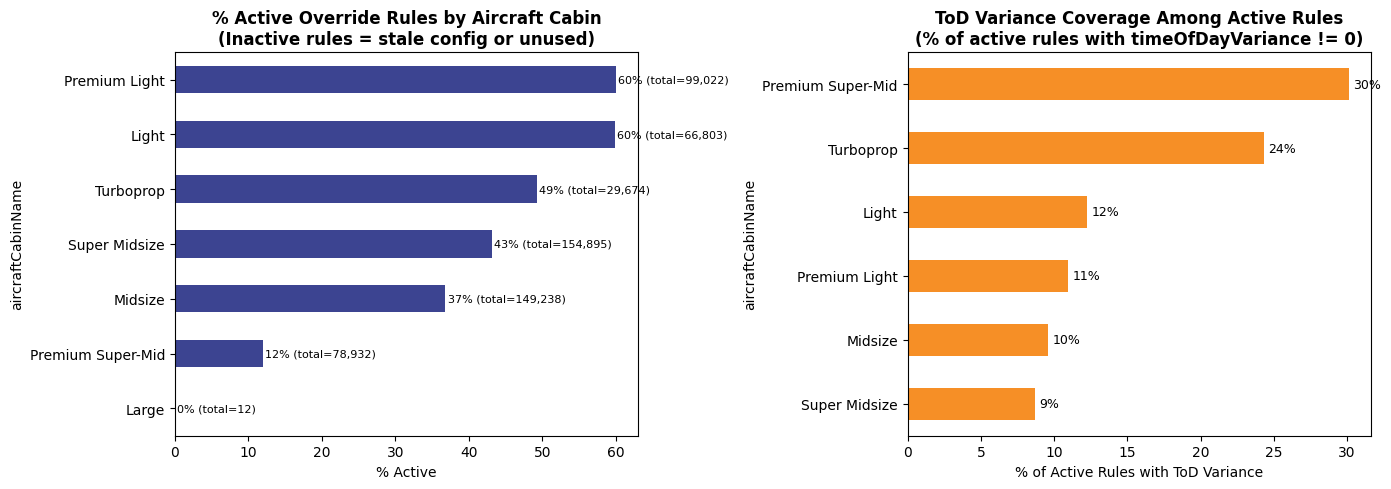

Total rules          : 578,576
Active               : 245,370 (42%)
Active + ToD set     : 28,909
Active without ToD   : 216,461


In [37]:
# Q11 — Pricing override health check
po['active_label'] = po['active'].map({True:'Active', False:'Inactive'})
po['has_tod']      = po['timeOfDayVariance'].fillna(0) != 0

# Active vs inactive by cabin
health = (
    po.groupby(['aircraftCabinName','active_label'])
    .size()
    .unstack('active_label')
    .fillna(0)
    .astype(int)
)
health['total'] = health.sum(axis=1)
health['active_pct'] = health.get('Active',0) / health['total'] * 100
health = health.sort_values('active_pct', ascending=True)

# ToD coverage among active rules only
tod_coverage = (
    po[po['active']==True]
    .groupby('aircraftCabinName')['has_tod']
    .mean() * 100
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

health['active_pct'].plot(kind='barh', ax=axes[0], color=C1, alpha=0.85)
axes[0].set_title('% Active Override Rules by Aircraft Cabin\n(Inactive rules = stale config or unused)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% Active')
for i, (pct, tot) in enumerate(zip(health['active_pct'], health['total'])):
    axes[0].text(pct+0.3, i, f'{pct:.0f}% (total={tot:,})', va='center', fontsize=8)

tod_coverage.plot(kind='barh', ax=axes[1], color=C2, alpha=0.85)
axes[1].set_title('ToD Variance Coverage Among Active Rules\n(% of active rules with timeOfDayVariance != 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% of Active Rules with ToD Variance')
for i, pct in enumerate(tod_coverage):
    axes[1].text(pct+0.3, i, f'{pct:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('qa_override_health.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total rules          : {len(po):,}')
print(f'Active               : {po["active"].sum():,} ({po["active"].mean()*100:.0f}%)')
print(f'Active + ToD set     : {(po["active"] & po["has_tod"]).sum():,}')
print(f'Active without ToD   : {(po["active"] & ~po["has_tod"]).sum():,}')